In [16]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

from sklearn.decomposition import PCA

# 1 Load Data

In [2]:
step2_dir = "./results_step2"

user_embeddings = np.load(f"{step2_dir}/user_embeddings.npy")
item_embeddings = np.load(f"{step2_dir}/item_embeddings.npy")

user_index_table = pd.read_csv(f"{step2_dir}/user_index_table.csv")
item_index_table = pd.read_csv(f"{step2_dir}/item_index_table.csv")

load_summary = pd.DataFrame([
    {
        "object": "user_embeddings",
        "shape": user_embeddings.shape,
    },
    {
        "object": "item_embeddings",
        "shape": item_embeddings.shape,
    },
    {
        "object": "user_index_table",
        "shape": user_index_table.shape,
    },
    {
        "object": "item_index_table",
        "shape": item_index_table.shape,
    },
])

display(load_summary)

display(user_index_table.head())
display(item_index_table.head())

,object,shape
0,user_embeddings,"(4722, 64)"
1,item_embeddings,"(3250, 64)"
2,user_index_table,"(4722, 2)"
3,item_index_table,"(3250, 2)"


,user_idx,user_id
0,0,1
1,1,2
2,2,3
3,3,5
4,4,6


,item_idx,movie_id
0,0,1
1,1,2
2,2,3
3,3,4
4,4,5


### Embedding Checks

Before clustering, we verify that:

- the number of user embeddings matches the user index table;
- the number of item embeddings matches the item index table;
- all embedding values are finite;
- embeddings have a reasonable numeric range.

This is a necessary sanity check before using distance-based clustering.

In [3]:
embedding_check = pd.DataFrame([
    {
        "object": "user_embeddings",
        "rows": user_embeddings.shape[0],
        "dimensions": user_embeddings.shape[1],
        "min_value": float(user_embeddings.min()),
        "max_value": float(user_embeddings.max()),
        "mean_value": float(user_embeddings.mean()),
        "std_value": float(user_embeddings.std()),
        "all_finite": bool(np.isfinite(user_embeddings).all()),
    },
    {
        "object": "item_embeddings",
        "rows": item_embeddings.shape[0],
        "dimensions": item_embeddings.shape[1],
        "min_value": float(item_embeddings.min()),
        "max_value": float(item_embeddings.max()),
        "mean_value": float(item_embeddings.mean()),
        "std_value": float(item_embeddings.std()),
        "all_finite": bool(np.isfinite(item_embeddings).all()),
    },
])

display(embedding_check)

assert len(user_index_table) == user_embeddings.shape[0]
assert len(item_index_table) == item_embeddings.shape[0]
assert np.isfinite(user_embeddings).all()
assert np.isfinite(item_embeddings).all()

,object,rows,dimensions,min_value,max_value,mean_value,std_value,all_finite
0,user_embeddings,4722,64,-0.857286,0.818325,0.003990,0.181612,True
1,item_embeddings,3250,64,-1.060074,1.140021,-0.000921,0.196268,True


# 2 User Embedding Scale and Preprocessing Decision

DBSCAN is distance-based, so preprocessing matters.

We focus on user embeddings because the final project needs group recommendation. User clusters can later be used to create:

- homogeneous groups from the same taste community;
- diverse groups across different taste communities;
- groups including noise/outlier users.

Before choosing DBSCAN parameters, we inspect the scale of user embeddings and compare simple preprocessing options.

In [4]:
# Raw user embeddings
user_embeddings_raw = user_embeddings.copy()

# Option 1: standardize each embedding dimension
scaler = StandardScaler()
user_embeddings_standardized = scaler.fit_transform(user_embeddings_raw)

# Option 2: L2-normalize raw embeddings
user_embeddings_l2 = normalize(
    user_embeddings_raw,
    norm="l2",
)

# Option 3: standardize first, then L2-normalize
user_embeddings_standardized_l2 = normalize(
    user_embeddings_standardized,
    norm="l2",
)


def summarize_embedding_matrix(name, matrix):
    row_norms = np.linalg.norm(matrix, axis=1)
    dim_std = matrix.std(axis=0)

    return {
        "version": name,
        "rows": matrix.shape[0],
        "dimensions": matrix.shape[1],
        "global_mean": round(float(matrix.mean()), 6),
        "global_std": round(float(matrix.std()), 6),
        "min_value": round(float(matrix.min()), 6),
        "max_value": round(float(matrix.max()), 6),
        "avg_l2_norm": round(float(row_norms.mean()), 6),
        "min_l2_norm": round(float(row_norms.min()), 6),
        "max_l2_norm": round(float(row_norms.max()), 6),
        "min_dimension_std": round(float(dim_std.min()), 6),
        "max_dimension_std": round(float(dim_std.max()), 6),
    }


preprocessing_summary = pd.DataFrame([
    summarize_embedding_matrix("raw", user_embeddings_raw),
    summarize_embedding_matrix("standardized", user_embeddings_standardized),
    summarize_embedding_matrix("l2_normalized_raw", user_embeddings_l2),
    summarize_embedding_matrix("standardized_then_l2", user_embeddings_standardized_l2),
])

display(preprocessing_summary)

,version,rows,dimensions,global_mean,global_std,min_value,max_value,avg_l2_norm,min_l2_norm,max_l2_norm,min_dimension_std,max_dimension_std
0,raw,4722,64,0.003990,0.181612,-0.857286,0.818325,1.382586,0.211152,2.430290,0.103449,0.229068
1,standardized,4722,64,-0.000000,1.000000,-5.717645,5.464437,7.547279,1.174033,17.159935,0.999999,1.000001
2,l2_normalized_raw,4722,64,0.002856,0.124967,-0.600114,0.501972,1.000000,1.000000,1.000000,0.068146,0.158246
3,standardized_then_l2,4722,64,-0.000394,0.124999,-0.484343,0.470737,1.000000,1.000000,1.000000,0.122139,0.128079


### 2.1 Choose DBSCAN Input Space

For the main DBSCAN experiment, we cluster users rather than items.

This choice is motivated by the goal of group recommendation: user clusters can be interpreted as dense preference communities, which are directly useful for creating or analyzing recommendation groups.

We use the BPR user embeddings learned in Step 2. Each user is represented by a 64-dimensional vector.

For preprocessing, we use standardized + L2-normalized user embeddings:

1. Standardization gives each embedding dimension comparable scale.
2. L2 normalization removes the effect of embedding magnitude and focuses DBSCAN on the direction of user preference vectors.

This is appropriate because we want users with similar preference patterns to be close, not merely users with large embedding norms.

In [ ]:
user_embeddings_dbscan = user_embeddings_standardized_l2

,clustering_target,input_matrix,n_points,dimensions,distance_metric,reason
0,users,user_embeddings_standardized_l2,4722,64,euclidean,cluster users into preference communities for ...


# 3 Choose `min_samples` Candidate Range

DBSCAN has two key parameters:

- `eps`: maximum distance between neighboring points;
- `min_samples`: minimum number of nearby users required to form a dense region.

Before tuning `eps`, we first define a reasonable range for `min_samples`.

`min_samples` should be interpreted relative to the number of users. Very small values may detect niche preference communities, while very large values require broad dense regions and may hide smaller communities.

We inspect candidate values as absolute counts and as shares of all users.

In [6]:
n_users_for_clustering = user_embeddings_dbscan.shape[0]

min_samples_scale_candidates = [5, 10, 20, 30, 50, 100, 200, 500]

min_samples_scale = pd.DataFrame({
    "min_samples": min_samples_scale_candidates,
    "share_of_users": [
        round(value / n_users_for_clustering, 4)
        for value in min_samples_scale_candidates
    ],
})

display(min_samples_scale)

,min_samples,share_of_users
0,5,0.0011
1,10,0.0021
2,20,0.0042
3,30,0.0064
4,50,0.0106
5,100,0.0212
6,200,0.0424
7,500,0.1059


# 4 k-distance Analysis for `eps`

After choosing a reasonable `min_samples` range, we estimate a useful `eps` range using k-distance analysis.

For each candidate `min_samples`, we compute the distance from every user to their k-th nearest neighbor, where `k = min_samples`.

If many users have similar k-neighbor distances, DBSCAN can form dense regions at that scale. Large jumps in the sorted k-distance curve suggest possible `eps` thresholds.

We use the k-distance summaries to define a compact `eps` grid for DBSCAN.

In [7]:
min_samples_candidates = [5, 10, 20, 30, 50, 100]

k_distance_rows = []

for min_samples in min_samples_candidates:
    neighbors = NearestNeighbors(
        n_neighbors=min_samples,
        metric="euclidean",
    )

    neighbors.fit(user_embeddings_dbscan)

    distances, indices = neighbors.kneighbors(user_embeddings_dbscan)

    k_distances = np.sort(distances[:, -1])

    for percentile in [0.50, 0.75, 0.90, 0.95, 0.99]:
        k_distance_rows.append({
            "min_samples": min_samples,
            "percentile": percentile,
            "k_distance": round(float(np.quantile(k_distances, percentile)), 4),
        })

k_distance_summary = pd.DataFrame(k_distance_rows)

display(k_distance_summary)

,min_samples,percentile,k_distance
0,5,0.50,0.8970
1,5,0.75,0.9769
2,5,0.90,1.0294
3,5,0.95,1.0530
4,5,0.99,1.0919
5,10,0.50,0.9294
6,10,0.75,1.0075
7,10,0.90,1.0583
8,10,0.95,1.0825
9,10,0.99,1.1207


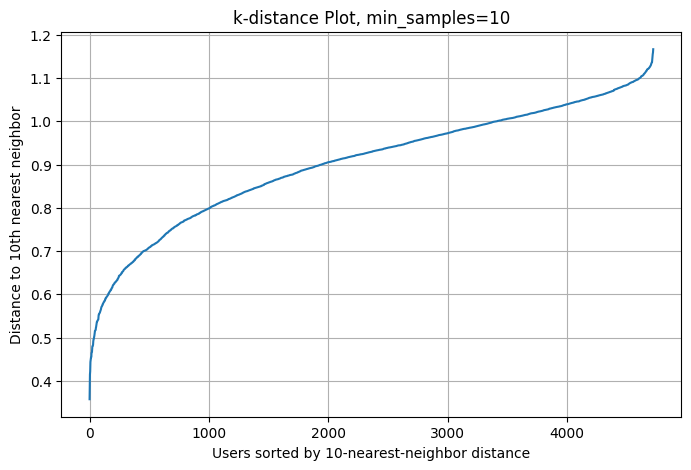

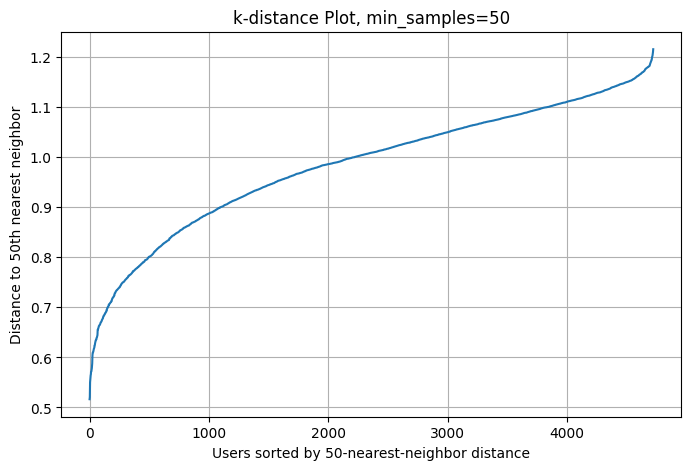

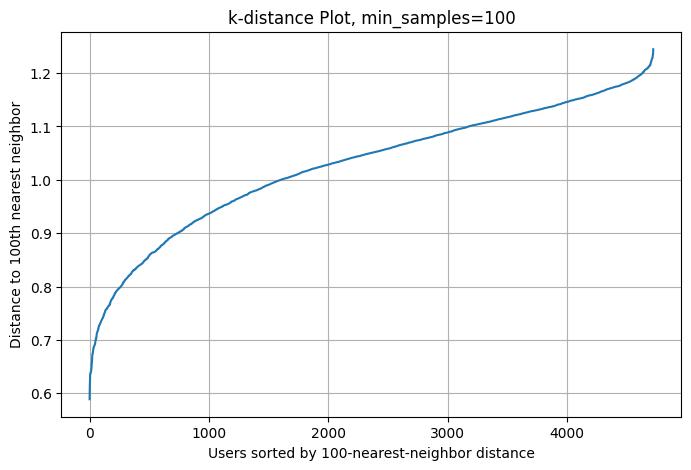

In [8]:
plot_min_samples = [10, 50, 100]

for min_samples in plot_min_samples:
    neighbors = NearestNeighbors(
        n_neighbors=min_samples,
        metric="euclidean",
    )

    neighbors.fit(user_embeddings_dbscan)

    distances, indices = neighbors.kneighbors(user_embeddings_dbscan)

    k_distances = np.sort(distances[:, -1])

    plt.figure(figsize=(8, 5))
    plt.plot(k_distances)
    plt.xlabel(f"Users sorted by {min_samples}-nearest-neighbor distance")
    plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
    plt.title(f"k-distance Plot, min_samples={min_samples}")
    plt.grid(True)
    plt.show()

# 5 DBSCAN Grid Search

Using the k-distance analysis, we now test a DBSCAN parameter grid.

We vary:

- `min_samples`: how many nearby users are required to form a dense region;
- `eps`: the maximum distance for users to be considered neighbors.

For each configuration, we record:

- number of clusters;
- number and share of noise users;
- largest cluster size;
- whether the solution is dominated by one giant cluster;
- whether there are tiny clusters that are too small to be useful.

A useful DBSCAN solution should usually produce more than one cluster, avoid excessive noise, and avoid one cluster containing almost all users.

In [9]:
from sklearn.cluster import DBSCAN

min_samples_candidates = [5, 10, 20, 30, 50, 100]
eps_values = [0.90, 0.95, 1.00, 1.03, 1.05, 1.08, 1.10, 1.12, 1.15, 1.18, 1.20]


def summarize_dbscan(labels):
    n_users = len(labels)

    cluster_labels = [
        label
        for label in sorted(set(labels))
        if label != -1
    ]

    n_clusters = len(cluster_labels)
    n_noise = int((labels == -1).sum())
    noise_share = n_noise / n_users

    if n_clusters == 0:
        return {
            "n_clusters": 0,
            "n_noise": n_noise,
            "noise_share": round(noise_share, 4),
            "largest_cluster_size": 0,
            "largest_cluster_share": 0.0,
            "smallest_cluster_size": 0,
            "median_cluster_size": 0.0,
        }

    cluster_sizes = [
        int((labels == cluster_id).sum())
        for cluster_id in cluster_labels
    ]

    return {
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_share": round(noise_share, 4),
        "largest_cluster_size": max(cluster_sizes),
        "largest_cluster_share": round(max(cluster_sizes) / n_users, 4),
        "smallest_cluster_size": min(cluster_sizes),
        "median_cluster_size": float(np.median(cluster_sizes)),
    }


dbscan_rows = []

for min_samples in min_samples_candidates:
    for eps in eps_values:
        dbscan_model = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric="euclidean",
        )

        labels = dbscan_model.fit_predict(user_embeddings_dbscan)
        summary = summarize_dbscan(labels)

        dbscan_rows.append({
            "eps": eps,
            "min_samples": min_samples,
            **summary,
        })

dbscan_grid = pd.DataFrame(dbscan_rows)

print("DBSCAN configurations tested:", len(dbscan_grid))

DBSCAN configurations tested: 66


### 5.1 Grid Analysis

Instead of inspecting all DBSCAN configurations manually, we summarize whether each configuration has common problems.

The main failure modes are:

- only one cluster;
- one giant cluster;
- too much noise;
- tiny secondary clusters.

This helps decide whether DBSCAN finds meaningful user communities in the full embedding space.

In [10]:
dbscan_grid_analysis = dbscan_grid.copy()

dbscan_grid_analysis["one_cluster_only"] = (
    dbscan_grid_analysis["n_clusters"] == 1
)

dbscan_grid_analysis["giant_cluster"] = (
    dbscan_grid_analysis["largest_cluster_share"] >= 0.90
)

dbscan_grid_analysis["high_noise"] = (
    dbscan_grid_analysis["noise_share"] >= 0.40
)

dbscan_grid_analysis["tiny_cluster_problem"] = (
    (dbscan_grid_analysis["n_clusters"] > 1)
    & (dbscan_grid_analysis["smallest_cluster_size"] < 20)
)

dbscan_grid_analysis["potentially_useful"] = (
    (dbscan_grid_analysis["n_clusters"] >= 2)
    & (dbscan_grid_analysis["noise_share"] < 0.40)
    & (dbscan_grid_analysis["largest_cluster_share"] < 0.90)
    & (dbscan_grid_analysis["smallest_cluster_size"] >= 20)
)

grid_summary = pd.DataFrame([
    {
        "condition": "all configurations",
        "count": len(dbscan_grid_analysis),
    },
    {
        "condition": "more than one cluster",
        "count": int((dbscan_grid_analysis["n_clusters"] > 1).sum()),
    },
    {
        "condition": "one cluster only",
        "count": int(dbscan_grid_analysis["one_cluster_only"].sum()),
    },
    {
        "condition": "giant cluster share >= 90%",
        "count": int(dbscan_grid_analysis["giant_cluster"].sum()),
    },
    {
        "condition": "noise share >= 40%",
        "count": int(dbscan_grid_analysis["high_noise"].sum()),
    },
    {
        "condition": "multi-cluster but smallest cluster < 20 users",
        "count": int(dbscan_grid_analysis["tiny_cluster_problem"].sum()),
    },
    {
        "condition": "potentially useful configurations",
        "count": int(dbscan_grid_analysis["potentially_useful"].sum()),
    },
])

display(grid_summary)

,condition,count
0,all configurations,66
1,more than one cluster,1
2,one cluster only,65
3,giant cluster share >= 90%,51
4,noise share >= 40%,3
5,multi-cluster but smallest cluster < 20 users,1
6,potentially useful configurations,0


In [11]:
multi_cluster_configs = (
    dbscan_grid_analysis[dbscan_grid_analysis["n_clusters"] > 1]
    .sort_values(
        ["n_clusters", "largest_cluster_share", "noise_share"],
        ascending=[False, True, True],
    )
)

candidate_configs = (
    dbscan_grid_analysis[dbscan_grid_analysis["potentially_useful"]]
    .sort_values(
        ["n_clusters", "noise_share", "largest_cluster_share"],
        ascending=[False, True, True],
    )
)

print("Configurations with more than one cluster:")
display(multi_cluster_configs)

print("Potentially useful configurations:")
display(candidate_configs)

Configurations with more than one cluster:


,eps,min_samples,n_clusters,n_noise,noise_share,largest_cluster_size,largest_cluster_share,smallest_cluster_size,median_cluster_size,one_cluster_only,giant_cluster,high_noise,tiny_cluster_problem,potentially_useful
2,1.0,5,2,325,0.0688,4395,0.9307,2,2198.5,False,True,False,True,False


Potentially useful configurations:


,eps,min_samples,n_clusters,n_noise,noise_share,largest_cluster_size,largest_cluster_share,smallest_cluster_size,median_cluster_size,one_cluster_only,giant_cluster,high_noise,tiny_cluster_problem,potentially_useful


# 6 PCA Dimensionality Reduction

Full-space DBSCAN did not find useful dense user communities.

As a second experiment, we reduce the 64-dimensional user embedding space with PCA. 

PCA can remove noisy dimensions and make distance-based clustering more stable.

We first inspect explained variance to choose a reasonable reduced dimensionality.

In [ ]:
pca_full = PCA(random_state=42)
pca_full.fit(user_embeddings_dbscan)

explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

pca_variance_summary = pd.DataFrame({
    "n_components": list(range(1, len(explained_variance) + 1)),
    "cumulative_explained_variance": explained_variance,
})

display(pca_variance_summary.head(15))

for threshold in [0.50, 0.70, 0.80, 0.90, 0.95]:
    n_components_needed = int(np.searchsorted(explained_variance, threshold) + 1)
    print(
        f"Components needed for {int(threshold * 100)}% variance:",
        n_components_needed
    )

,n_components,cumulative_explained_variance
0,1,0.178819
1,2,0.289547
2,3,0.361499
3,4,0.411116
4,5,0.455707
5,6,0.486946
6,7,0.514029
7,8,0.538526
8,9,0.560471
9,10,0.580436


Components needed for 50% variance: 7
Components needed for 70% variance: 18
Components needed for 80% variance: 27
Components needed for 90% variance: 40
Components needed for 95% variance: 49


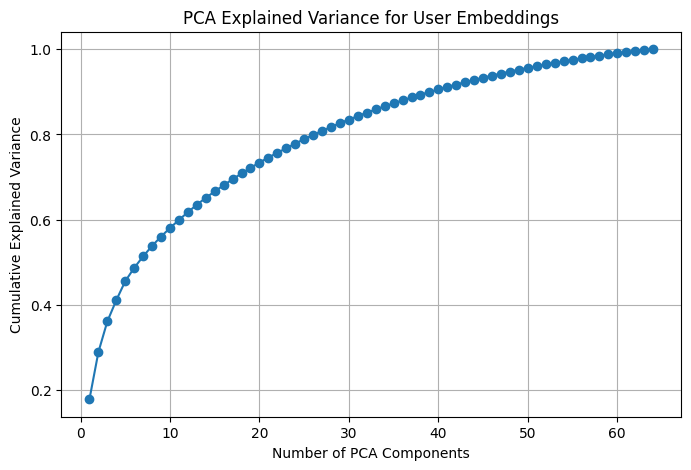

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(
    pca_variance_summary["n_components"],
    pca_variance_summary["cumulative_explained_variance"],
    marker="o",
)
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance for User Embeddings")
plt.grid(True)
plt.show()

# 7 DBSCAN after PCA

Full-space DBSCAN did not produce useful clusters, so we test whether dimensionality reduction makes density-based clustering more stable.

We use PCA-reduced user embeddings with several component counts:

- 5 components: very compact taste representation;
- 10 components: moderate compression;
- 18 components: about 70% explained variance;
- 27 components: about 80% explained variance.

After PCA, we L2-normalize the reduced vectors before DBSCAN. This keeps distances comparable and avoids users with larger PCA vector norms dominating the distance calculation.

For each PCA dimension, we run a compact DBSCAN grid search and summarize whether useful clusters appear.

In [17]:
pca_components_candidates = [5, 10, 18, 27]

min_samples_candidates = [5, 10, 20, 30, 50, 100]
eps_values = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00, 1.10, 1.20]


def summarize_dbscan(labels):
    n_users = len(labels)

    cluster_labels = [
        label
        for label in sorted(set(labels))
        if label != -1
    ]

    n_clusters = len(cluster_labels)
    n_noise = int((labels == -1).sum())
    noise_share = n_noise / n_users

    if n_clusters == 0:
        return {
            "n_clusters": 0,
            "n_noise": n_noise,
            "noise_share": round(noise_share, 4),
            "largest_cluster_size": 0,
            "largest_cluster_share": 0.0,
            "smallest_cluster_size": 0,
            "median_cluster_size": 0.0,
        }

    cluster_sizes = [
        int((labels == cluster_id).sum())
        for cluster_id in cluster_labels
    ]

    return {
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_share": round(noise_share, 4),
        "largest_cluster_size": max(cluster_sizes),
        "largest_cluster_share": round(max(cluster_sizes) / n_users, 4),
        "smallest_cluster_size": min(cluster_sizes),
        "median_cluster_size": float(np.median(cluster_sizes)),
    }


pca_dbscan_rows = []

for n_components in pca_components_candidates:
    pca = PCA(
        n_components=n_components,
        random_state=42,
    )

    user_embeddings_pca = pca.fit_transform(user_embeddings_dbscan)
    user_embeddings_pca_l2 = normalize(user_embeddings_pca, norm="l2")

    explained_variance = pca.explained_variance_ratio_.sum()

    for min_samples in min_samples_candidates:
        for eps in eps_values:
            dbscan_model = DBSCAN(
                eps=eps,
                min_samples=min_samples,
                metric="euclidean",
            )

            labels = dbscan_model.fit_predict(user_embeddings_pca_l2)
            summary = summarize_dbscan(labels)

            pca_dbscan_rows.append({
                "pca_components": n_components,
                "explained_variance": round(float(explained_variance), 4),
                "eps": eps,
                "min_samples": min_samples,
                **summary,
            })

pca_dbscan_grid = pd.DataFrame(pca_dbscan_rows)

print("PCA DBSCAN configurations tested:", len(pca_dbscan_grid))

PCA DBSCAN configurations tested: 240


### 7.1 Analyze PCA DBSCAN Results

We summarize the PCA + DBSCAN grid search using the same practical criteria as before.

A useful configuration should:

- produce at least 2 clusters;
- avoid excessive noise;
- avoid one giant cluster;
- avoid tiny clusters.

This tells us whether PCA reveals actionable user communities for group recommendation.

In [18]:
pca_dbscan_analysis = pca_dbscan_grid.copy()

pca_dbscan_analysis["one_cluster_only"] = (
    pca_dbscan_analysis["n_clusters"] == 1
)

pca_dbscan_analysis["giant_cluster"] = (
    pca_dbscan_analysis["largest_cluster_share"] >= 0.90
)

pca_dbscan_analysis["high_noise"] = (
    pca_dbscan_analysis["noise_share"] >= 0.40
)

pca_dbscan_analysis["tiny_cluster_problem"] = (
    (pca_dbscan_analysis["n_clusters"] > 1)
    & (pca_dbscan_analysis["smallest_cluster_size"] < 20)
)

pca_dbscan_analysis["potentially_useful"] = (
    (pca_dbscan_analysis["n_clusters"] >= 2)
    & (pca_dbscan_analysis["noise_share"] < 0.40)
    & (pca_dbscan_analysis["largest_cluster_share"] < 0.90)
    & (pca_dbscan_analysis["smallest_cluster_size"] >= 20)
)

pca_grid_summary = pd.DataFrame([
    {
        "condition": "all configurations",
        "count": len(pca_dbscan_analysis),
    },
    {
        "condition": "more than one cluster",
        "count": int((pca_dbscan_analysis["n_clusters"] > 1).sum()),
    },
    {
        "condition": "one cluster only",
        "count": int(pca_dbscan_analysis["one_cluster_only"].sum()),
    },
    {
        "condition": "giant cluster share >= 90%",
        "count": int(pca_dbscan_analysis["giant_cluster"].sum()),
    },
    {
        "condition": "noise share >= 40%",
        "count": int(pca_dbscan_analysis["high_noise"].sum()),
    },
    {
        "condition": "multi-cluster but smallest cluster < 20 users",
        "count": int(pca_dbscan_analysis["tiny_cluster_problem"].sum()),
    },
    {
        "condition": "potentially useful configurations",
        "count": int(pca_dbscan_analysis["potentially_useful"].sum()),
    },
])

display(pca_grid_summary)

,condition,count
0,all configurations,240
1,more than one cluster,49
2,one cluster only,170
3,giant cluster share >= 90%,136
4,noise share >= 40%,84
5,multi-cluster but smallest cluster < 20 users,19
6,potentially useful configurations,0


In [19]:
pca_candidate_configs = (
    pca_dbscan_analysis[pca_dbscan_analysis["potentially_useful"]]
    .sort_values(
        ["n_clusters", "noise_share", "largest_cluster_share"],
        ascending=[False, True, True],
    )
)

display(pca_candidate_configs.head(20))

,pca_components,explained_variance,eps,min_samples,n_clusters,n_noise,noise_share,largest_cluster_size,largest_cluster_share,smallest_cluster_size,median_cluster_size,one_cluster_only,giant_cluster,high_noise,tiny_cluster_problem,potentially_useful


### 7.3 Inspect Best Imperfect PCA DBSCAN Configurations

PCA increased the number of multi-cluster DBSCAN solutions, but none satisfied all quality criteria.

We inspect the best imperfect configurations to understand why they were rejected.

In [20]:
multi_cluster_pca_configs = (
    pca_dbscan_analysis[pca_dbscan_analysis["n_clusters"] > 1]
    .sort_values(
        ["n_clusters", "noise_share", "largest_cluster_share"],
        ascending=[False, True, True],
    )
)

display(multi_cluster_pca_configs.head(20))

,pca_components,explained_variance,eps,min_samples,n_clusters,n_noise,noise_share,largest_cluster_size,largest_cluster_share,smallest_cluster_size,median_cluster_size,one_cluster_only,giant_cluster,high_noise,tiny_cluster_problem,potentially_useful
0,5,0.4557,0.3,5,20,197,0.0417,4432,0.9386,1,4.0,False,True,False,True,False
61,10,0.5804,0.4,5,17,3393,0.7186,713,0.1510,4,5.0,False,False,True,True,False
62,10,0.5804,0.5,5,11,1556,0.3295,3116,0.6599,4,5.0,False,False,False,True,False
122,18,0.7085,0.5,5,7,3895,0.8249,514,0.1089,3,8.0,False,False,True,True,False
60,10,0.5804,0.3,5,7,4445,0.9413,201,0.0426,5,7.0,False,False,True,True,False
10,5,0.4557,0.3,10,5,1065,0.2255,3622,0.7670,3,6.0,False,False,False,True,False
20,5,0.4557,0.3,20,4,2665,0.5644,1121,0.2374,15,460.5,False,False,True,True,False
71,10,0.5804,0.4,10,4,3820,0.8090,533,0.1129,5,182.0,False,False,True,True,False
63,10,0.5804,0.6,5,3,277,0.0587,4440,0.9403,2,3.0,False,True,False,True,False
185,27,0.8084,0.8,5,3,1192,0.2524,3521,0.7457,4,5.0,False,False,False,True,False


In [21]:
rejection_summary = pd.DataFrame([
    {
        "condition": "multi-cluster configurations",
        "count": int((pca_dbscan_analysis["n_clusters"] > 1).sum()),
    },
    {
        "condition": "multi-cluster + acceptable noise",
        "count": int(
            (
                (pca_dbscan_analysis["n_clusters"] > 1)
                & (pca_dbscan_analysis["noise_share"] < 0.40)
            ).sum()
        ),
    },
    {
        "condition": "multi-cluster + no giant cluster",
        "count": int(
            (
                (pca_dbscan_analysis["n_clusters"] > 1)
                & (pca_dbscan_analysis["largest_cluster_share"] < 0.90)
            ).sum()
        ),
    },
    {
        "condition": "multi-cluster + no tiny cluster",
        "count": int(
            (
                (pca_dbscan_analysis["n_clusters"] > 1)
                & (pca_dbscan_analysis["smallest_cluster_size"] >= 20)
            ).sum()
        ),
    },
    {
        "condition": "passes all criteria",
        "count": int(pca_dbscan_analysis["potentially_useful"].sum()),
    },
])

display(rejection_summary)

,condition,count
0,multi-cluster configurations,49
1,multi-cluster + acceptable noise,6
2,multi-cluster + no giant cluster,46
3,multi-cluster + no tiny cluster,30
4,passes all criteria,0


### 7.4 User DBSCAN Decision

DBSCAN was tested on user embeddings in both the full 64-dimensional space and PCA-reduced spaces.

The full-space experiment mostly produced one giant cluster. PCA made multi-cluster solutions more common, but no configuration satisfied all quality criteria. The main issues were giant clusters, tiny unstable clusters, and in some cases high noise.

Therefore, we do not select user DBSCAN clusters as the final clustering solution at this stage. We next test item embeddings to determine whether item communities provide more actionable structure for group recommendation.

In [22]:
user_dbscan_decision = pd.DataFrame([
    {
        "experiment": "full_64d_user_embeddings",
        "tested_configurations": len(dbscan_grid_analysis),
        "multi_cluster_configurations": int((dbscan_grid_analysis["n_clusters"] > 1).sum()),
        "useful_configurations": int(dbscan_grid_analysis["potentially_useful"].sum()),
        "decision": "not_selected",
        "reason": "mostly one giant cluster; only multi-cluster case had a tiny 2-user cluster",
    },
    {
        "experiment": "pca_user_embeddings",
        "tested_configurations": len(pca_dbscan_analysis),
        "multi_cluster_configurations": int((pca_dbscan_analysis["n_clusters"] > 1).sum()),
        "useful_configurations": int(pca_dbscan_analysis["potentially_useful"].sum()),
        "decision": "not_selected",
        "reason": "PCA created more multi-cluster cases, but none passed all stability criteria",
    },
])

display(user_dbscan_decision)

,experiment,tested_configurations,multi_cluster_configurations,useful_configurations,decision,reason
0,full_64d_user_embeddings,66,1,0,not_selected,mostly one giant cluster; only multi-cluster c...
1,pca_user_embeddings,240,49,0,not_selected,"PCA created more multi-cluster cases, but none..."


# 8 Item Embedding Clustering Setup

User-side DBSCAN did not produce stable actionable communities.

We now test DBSCAN on item embeddings. Item clustering may be more actionable for group recommendation because movies can form clearer preference neighborhoods such as genres, themes, popularity groups, or taste niches.

We use the same preprocessing logic as for users:

1. standardize embedding dimensions;
2. L2-normalize each item vector;
3. use Euclidean distance on the normalized vectors.

In [23]:
item_embeddings_raw = item_embeddings.copy()

item_scaler = StandardScaler()
item_embeddings_standardized = item_scaler.fit_transform(item_embeddings_raw)

item_embeddings_dbscan = normalize(
    item_embeddings_standardized,
    norm="l2",
)

item_preprocessing_summary = pd.DataFrame([
    {
        "version": "raw",
        "rows": item_embeddings_raw.shape[0],
        "dimensions": item_embeddings_raw.shape[1],
        "global_mean": round(float(item_embeddings_raw.mean()), 6),
        "global_std": round(float(item_embeddings_raw.std()), 6),
        "avg_l2_norm": round(float(np.linalg.norm(item_embeddings_raw, axis=1).mean()), 6),
        "min_l2_norm": round(float(np.linalg.norm(item_embeddings_raw, axis=1).min()), 6),
        "max_l2_norm": round(float(np.linalg.norm(item_embeddings_raw, axis=1).max()), 6),
    },
    {
        "version": "standardized_then_l2",
        "rows": item_embeddings_dbscan.shape[0],
        "dimensions": item_embeddings_dbscan.shape[1],
        "global_mean": round(float(item_embeddings_dbscan.mean()), 6),
        "global_std": round(float(item_embeddings_dbscan.std()), 6),
        "avg_l2_norm": round(float(np.linalg.norm(item_embeddings_dbscan, axis=1).mean()), 6),
        "min_l2_norm": round(float(np.linalg.norm(item_embeddings_dbscan, axis=1).min()), 6),
        "max_l2_norm": round(float(np.linalg.norm(item_embeddings_dbscan, axis=1).max()), 6),
    },
])

display(item_preprocessing_summary)

,version,rows,dimensions,global_mean,global_std,avg_l2_norm,min_l2_norm,max_l2_norm
0,raw,3250,64,-0.000921,0.196268,1.362933,0.039897,4.550706
1,standardized_then_l2,3250,64,-0.000355,0.124999,1.000000,1.000000,1.000000


### 8.1 Load Movie data

To interpret item clusters, we attach movie titles and genres to the item index table.

This does not affect DBSCAN itself, but it helps us understand whether discovered item clusters correspond to meaningful movie groups such as genres, themes, or taste niches.

In [24]:
step1_dir = "./results_step1"

movies = pd.read_parquet(f"{step1_dir}/movies.parquet")

item_metadata = item_index_table.merge(
    movies,
    on="movie_id",
    how="left",
)

missing_movie_metadata = item_metadata["title"].isna().sum()

display(item_metadata.head())

print("Items without movie metadata:", missing_movie_metadata)

assert missing_movie_metadata == 0

,item_idx,movie_id,title,genres
0,0,1,Toy Story (1995),Animation|Children's|Comedy
1,1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,2,3,Grumpier Old Men (1995),Comedy|Romance
3,3,4,Waiting to Exhale (1995),Comedy|Drama
4,4,5,Father of the Bride Part II (1995),Comedy


Items without movie metadata: 0


# 9 Item k-Distance Analysis

Before running DBSCAN on item embeddings, we inspect the distance scale.

For each candidate `min_samples`, we compute the distance from each movie to its k-th nearest neighbor. This helps choose a reasonable range of `eps` values for the DBSCAN grid search.

Small `eps` values are stricter and may create more noise. Large `eps` values are looser and may merge many movies into one large cluster.

In [25]:
n_items_for_clustering = item_embeddings_dbscan.shape[0]

min_samples_scale_candidates = [5, 10, 20, 30, 50, 100, 200]

item_min_samples_scale = pd.DataFrame({
    "min_samples": min_samples_scale_candidates,
    "share_of_items": [
        round(value / n_items_for_clustering, 4)
        for value in min_samples_scale_candidates
    ],
})

display(item_min_samples_scale)

,min_samples,share_of_items
0,5,0.0015
1,10,0.0031
2,20,0.0062
3,30,0.0092
4,50,0.0154
5,100,0.0308
6,200,0.0615


In [26]:
item_min_samples_candidates = [5, 10, 20, 30, 50, 100]

item_k_distance_rows = []

for min_samples in item_min_samples_candidates:
    neighbors = NearestNeighbors(
        n_neighbors=min_samples,
        metric="euclidean",
    )

    neighbors.fit(item_embeddings_dbscan)

    distances, indices = neighbors.kneighbors(item_embeddings_dbscan)

    k_distances = np.sort(distances[:, -1])

    for percentile in [0.50, 0.75, 0.90, 0.95, 0.99]:
        item_k_distance_rows.append({
            "min_samples": min_samples,
            "percentile": percentile,
            "k_distance": round(float(np.quantile(k_distances, percentile)), 4),
        })

item_k_distance_summary = pd.DataFrame(item_k_distance_rows)

display(item_k_distance_summary)

,min_samples,percentile,k_distance
0,5,0.50,0.7569
1,5,0.75,0.9043
2,5,0.90,0.9994
3,5,0.95,1.0355
4,5,0.99,1.0988
5,10,0.50,0.7873
6,10,0.75,0.9393
7,10,0.90,1.0367
8,10,0.95,1.0719
9,10,0.99,1.1308


# 10 Item DBSCAN Grid Search

Using the item k-distance analysis, we run DBSCAN on preprocessed item embeddings.

Compared with user clustering, item clustering may be more actionable because movie embeddings can form clearer groups around genres, themes, popularity patterns, or taste niches.

For item clusters, we allow moderately small clusters because niche movie groups can still be useful. However, we reject configurations with excessive noise, one giant cluster, or tiny unstable clusters.

In [28]:
item_min_samples_candidates = [5, 10, 20, 30, 50, 100]
item_eps_values = [0.80, 0.90, 1.00, 1.05, 1.10, 1.15, 1.20, 1.25]


def summarize_dbscan(labels):
    n_points = len(labels)

    cluster_labels = [
        label
        for label in sorted(set(labels))
        if label != -1
    ]

    n_clusters = len(cluster_labels)
    n_noise = int((labels == -1).sum())
    noise_share = n_noise / n_points

    if n_clusters == 0:
        return {
            "n_clusters": 0,
            "n_noise": n_noise,
            "noise_share": round(noise_share, 4),
            "largest_cluster_size": 0,
            "largest_cluster_share": 0.0,
            "smallest_cluster_size": 0,
            "median_cluster_size": 0.0,
        }

    cluster_sizes = [
        int((labels == cluster_id).sum())
        for cluster_id in cluster_labels
    ]

    return {
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_share": round(noise_share, 4),
        "largest_cluster_size": max(cluster_sizes),
        "largest_cluster_share": round(max(cluster_sizes) / n_points, 4),
        "smallest_cluster_size": min(cluster_sizes),
        "median_cluster_size": float(np.median(cluster_sizes)),
    }


item_dbscan_rows = []

for min_samples in item_min_samples_candidates:
    for eps in item_eps_values:
        dbscan_model = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric="euclidean",
        )

        labels = dbscan_model.fit_predict(item_embeddings_dbscan)
        summary = summarize_dbscan(labels)

        item_dbscan_rows.append({
            "eps": eps,
            "min_samples": min_samples,
            **summary,
        })

item_dbscan_grid = pd.DataFrame(item_dbscan_rows)

print("Item DBSCAN configurations tested:", len(item_dbscan_grid))
display(item_dbscan_grid)

Item DBSCAN configurations tested: 48


,eps,min_samples,n_clusters,n_noise,noise_share,largest_cluster_size,largest_cluster_share,smallest_cluster_size,median_cluster_size
0,0.80,5,2,1106,0.3403,2138,0.6578,6,1072.0
1,0.90,5,2,549,0.1689,2698,0.8302,3,1350.5
2,1.00,5,1,133,0.0409,3117,0.9591,3117,3117.0
3,1.05,5,1,33,0.0102,3217,0.9898,3217,3217.0
4,1.10,5,1,2,0.0006,3248,0.9994,3248,3248.0
5,1.15,5,1,0,0.0000,3250,1.0000,3250,3250.0
6,1.20,5,1,0,0.0000,3250,1.0000,3250,3250.0
7,1.25,5,1,0,0.0000,3250,1.0000,3250,3250.0
8,0.80,10,2,1160,0.3569,1159,0.3566,931,1045.0
9,0.90,10,1,592,0.1822,2658,0.8178,2658,2658.0


### 10.1 Analyze Item DBSCAN Results

We summarize the item DBSCAN grid search using practical quality criteria.

A useful item clustering should:

- produce several clusters;
- avoid classifying most movies as noise;
- avoid one giant cluster containing most movies;
- avoid very tiny clusters that are hard to interpret.

Because item communities can be smaller than user communities, we use a minimum cluster size of 10 movies.

In [29]:
item_dbscan_analysis = item_dbscan_grid.copy()

item_dbscan_analysis["one_cluster_only"] = (
    item_dbscan_analysis["n_clusters"] == 1
)

item_dbscan_analysis["giant_cluster"] = (
    item_dbscan_analysis["largest_cluster_share"] >= 0.80
)

item_dbscan_analysis["high_noise"] = (
    item_dbscan_analysis["noise_share"] >= 0.50
)

item_dbscan_analysis["tiny_cluster_problem"] = (
    (item_dbscan_analysis["n_clusters"] > 1)
    & (item_dbscan_analysis["smallest_cluster_size"] < 10)
)

item_dbscan_analysis["potentially_useful"] = (
    (item_dbscan_analysis["n_clusters"] >= 3)
    & (item_dbscan_analysis["noise_share"] < 0.50)
    & (item_dbscan_analysis["largest_cluster_share"] < 0.80)
    & (item_dbscan_analysis["smallest_cluster_size"] >= 10)
)

item_grid_summary = pd.DataFrame([
    {
        "condition": "all configurations",
        "count": len(item_dbscan_analysis),
    },
    {
        "condition": "more than one cluster",
        "count": int((item_dbscan_analysis["n_clusters"] > 1).sum()),
    },
    {
        "condition": "at least three clusters",
        "count": int((item_dbscan_analysis["n_clusters"] >= 3).sum()),
    },
    {
        "condition": "one cluster only",
        "count": int(item_dbscan_analysis["one_cluster_only"].sum()),
    },
    {
        "condition": "giant cluster share >= 80%",
        "count": int(item_dbscan_analysis["giant_cluster"].sum()),
    },
    {
        "condition": "noise share >= 50%",
        "count": int(item_dbscan_analysis["high_noise"].sum()),
    },
    {
        "condition": "multi-cluster but smallest cluster < 10 movies",
        "count": int(item_dbscan_analysis["tiny_cluster_problem"].sum()),
    },
    {
        "condition": "potentially useful configurations",
        "count": int(item_dbscan_analysis["potentially_useful"].sum()),
    },
])

display(item_grid_summary)

,condition,count
0,all configurations,48
1,more than one cluster,8
2,at least three clusters,0
3,one cluster only,40
4,giant cluster share >= 80%,39
5,noise share >= 50%,0
6,multi-cluster but smallest cluster < 10 movies,2
7,potentially useful configurations,0


In [30]:
item_candidate_configs = (
    item_dbscan_analysis[item_dbscan_analysis["potentially_useful"]]
    .sort_values(
        ["n_clusters", "noise_share", "largest_cluster_share"],
        ascending=[False, True, True],
    )
)

item_multi_cluster_configs = (
    item_dbscan_analysis[item_dbscan_analysis["n_clusters"] > 1]
    .sort_values(
        ["n_clusters", "noise_share", "largest_cluster_share"],
        ascending=[False, True, True],
    )
)

print("Potentially useful item DBSCAN configurations:")
display(item_candidate_configs.head(20))

print("All multi-cluster item DBSCAN configurations:")
display(item_multi_cluster_configs.head(20))

Potentially useful item DBSCAN configurations:


,eps,min_samples,n_clusters,n_noise,noise_share,largest_cluster_size,largest_cluster_share,smallest_cluster_size,median_cluster_size,one_cluster_only,giant_cluster,high_noise,tiny_cluster_problem,potentially_useful


All multi-cluster item DBSCAN configurations:


,eps,min_samples,n_clusters,n_noise,noise_share,largest_cluster_size,largest_cluster_share,smallest_cluster_size,median_cluster_size,one_cluster_only,giant_cluster,high_noise,tiny_cluster_problem,potentially_useful
1,0.9,5,2,549,0.1689,2698,0.8302,3,1350.5,False,True,False,True,False
41,0.9,100,2,758,0.2332,1341,0.4126,1151,1246.0,False,False,False,False,False
0,0.8,5,2,1106,0.3403,2138,0.6578,6,1072.0,False,False,False,True,False
8,0.8,10,2,1160,0.3569,1159,0.3566,931,1045.0,False,False,False,False,False
16,0.8,20,2,1210,0.3723,1141,0.3511,899,1020.0,False,False,False,False,False
24,0.8,30,2,1237,0.3806,1133,0.3486,880,1006.5,False,False,False,False,False
32,0.8,50,2,1278,0.3932,1118,0.3440,854,986.0,False,False,False,False,False
40,0.8,100,2,1334,0.4105,1102,0.3391,814,958.0,False,False,False,False,False


### Revised Item Candidate Selection

The initial item DBSCAN criterion required at least three clusters. However, the grid search shows several stable two-cluster solutions.

For item embeddings, a two-cluster solution can still be actionable if both clusters are large, noise is moderate, and the clusters are interpretable.

Therefore, we revise the item candidate criterion to allow at least two clusters, while keeping the stability requirements:

- noise share below 50%;
- no giant cluster;
- no tiny clusters.

In [31]:
item_dbscan_analysis["item_candidate"] = (
    (item_dbscan_analysis["n_clusters"] >= 2)
    & (item_dbscan_analysis["noise_share"] < 0.50)
    & (item_dbscan_analysis["largest_cluster_share"] < 0.80)
    & (item_dbscan_analysis["smallest_cluster_size"] >= 10)
)

item_candidate_configs = (
    item_dbscan_analysis[item_dbscan_analysis["item_candidate"]]
    .sort_values(
        ["noise_share", "min_samples", "largest_cluster_share"],
        ascending=[True, False, True],
    )
)

display(item_candidate_configs)

,eps,min_samples,n_clusters,n_noise,noise_share,largest_cluster_size,largest_cluster_share,smallest_cluster_size,median_cluster_size,one_cluster_only,giant_cluster,high_noise,tiny_cluster_problem,potentially_useful,item_candidate
41,0.9,100,2,758,0.2332,1341,0.4126,1151,1246.0,False,False,False,False,False,True
8,0.8,10,2,1160,0.3569,1159,0.3566,931,1045.0,False,False,False,False,False,True
16,0.8,20,2,1210,0.3723,1141,0.3511,899,1020.0,False,False,False,False,False,True
24,0.8,30,2,1237,0.3806,1133,0.3486,880,1006.5,False,False,False,False,False,True
32,0.8,50,2,1278,0.3932,1118,0.3440,854,986.0,False,False,False,False,False,True
40,0.8,100,2,1334,0.4105,1102,0.3391,814,958.0,False,False,False,False,False,True


# 11 Fit Selected Item DBSCAN and Inspect Clusters

The revised item-candidate selection produced several valid two-cluster solutions.

We select the most conservative useful configuration: the one with the lowest noise share and highest `min_samples`.

Before accepting it as the final DBSCAN result, we inspect the cluster sizes, genre composition, example movies, and noise points.

In [32]:
selected_item_config = item_candidate_configs.iloc[0]

final_item_eps = float(selected_item_config["eps"])
final_item_min_samples = int(selected_item_config["min_samples"])

selected_item_config_summary = pd.DataFrame([{
    "eps": final_item_eps,
    "min_samples": final_item_min_samples,
    "n_clusters": int(selected_item_config["n_clusters"]),
    "noise_share": float(selected_item_config["noise_share"]),
    "largest_cluster_share": float(selected_item_config["largest_cluster_share"]),
    "smallest_cluster_size": int(selected_item_config["smallest_cluster_size"]),
    "selection_reason": "lowest noise among stable item candidates, with strict min_samples",
}])

display(selected_item_config_summary)

,eps,min_samples,n_clusters,noise_share,largest_cluster_share,smallest_cluster_size,selection_reason
0,0.9,100,2,0.2332,0.4126,1151,"lowest noise among stable item candidates, wit..."


In [33]:
final_item_dbscan = DBSCAN(
    eps=final_item_eps,
    min_samples=final_item_min_samples,
    metric="euclidean",
)

item_cluster_labels = final_item_dbscan.fit_predict(item_embeddings_dbscan)

item_clusters = item_metadata.copy()
item_clusters["dbscan_cluster"] = item_cluster_labels

item_cluster_summary = (
    item_clusters
    .groupby("dbscan_cluster")
    .size()
    .reset_index(name="n_items")
    .sort_values("dbscan_cluster")
)

item_cluster_summary["share_items"] = (
    item_cluster_summary["n_items"] / len(item_clusters)
).round(4)

display(item_cluster_summary)

,dbscan_cluster,n_items,share_items
0,-1,758,0.2332
1,0,1341,0.4126
2,1,1151,0.3542


### 11.1 Genre Composition by Item Cluster

To interpret the item clusters, we inspect the most common genres inside each cluster.

Noise movies are also inspected because DBSCAN noise points may represent niche, unusual, or less consistently positioned movies.

In [34]:
item_cluster_genres = item_clusters.copy()

item_cluster_genres["genre"] = (
    item_cluster_genres["genres"]
    .fillna("")
    .str.split(r"\|")
)

item_cluster_genres = item_cluster_genres.explode("genre")

genre_counts = (
    item_cluster_genres
    .groupby(["dbscan_cluster", "genre"])
    .size()
    .reset_index(name="count")
)

genre_counts["cluster_total"] = (
    genre_counts
    .groupby("dbscan_cluster")["count"]
    .transform("sum")
)

genre_counts["share_in_cluster"] = (
    genre_counts["count"] / genre_counts["cluster_total"]
).round(4)

top_genres_by_cluster = (
    genre_counts
    .sort_values(
        ["dbscan_cluster", "count"],
        ascending=[True, False],
    )
    .groupby("dbscan_cluster")
    .head(8)
    .reset_index(drop=True)
)

display(top_genres_by_cluster)

,dbscan_cluster,genre,count,cluster_total,share_in_cluster
0,-1,Drama,280,1399,0.2001
1,-1,Comedy,267,1399,0.1909
2,-1,Romance,133,1399,0.0951
3,-1,Action,114,1399,0.0815
4,-1,Thriller,102,1399,0.0729
5,-1,Sci-Fi,85,1399,0.0608
6,-1,Adventure,81,1399,0.0579
7,-1,Horror,71,1399,0.0508
8,0,Comedy,501,2383,0.2102
9,0,Drama,344,2383,0.1444


### 11.2 Example Movies by Cluster

Genre counts give a high-level interpretation, but example movie titles make the clusters easier to understand.

We show a small sample of movies from each DBSCAN cluster, including the noise group.

In [35]:
for cluster_id in sorted(item_clusters["dbscan_cluster"].unique()):
    cluster_movies = item_clusters[item_clusters["dbscan_cluster"] == cluster_id]

    print(f"\nCluster {cluster_id}")
    print("Number of movies:", len(cluster_movies))

    display(
        cluster_movies[
            ["movie_id", "title", "genres"]
        ]
        .head(12)
    )


Cluster -1
Number of movies: 758


,movie_id,title,genres
5,6,Heat (1995),Action|Crime|Thriller
10,11,"American President, The (1995)",Comedy|Drama|Romance
13,14,Nixon (1995),Drama
15,16,Casino (1995),Drama|Thriller
17,18,Four Rooms (1995),Thriller
20,21,Get Shorty (1995),Action|Comedy|Drama
23,24,Powder (1995),Drama|Sci-Fi
24,25,Leaving Las Vegas (1995),Drama|Romance
33,35,Carrington (1995),Drama|Romance
36,39,Clueless (1995),Comedy|Romance



Cluster 0
Number of movies: 1341


,movie_id,title,genres
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children's
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller
11,12,Dracula: Dead and Loving It (1995),Comedy|Horror
12,13,Balto (1995),Animation|Children's



Cluster 1
Number of movies: 1151


,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
16,17,Sense and Sensibility (1995),Drama|Romance
25,26,Othello (1995),Drama
27,28,Persuasion (1995),Romance
28,29,"City of Lost Children, The (1995)",Adventure|Sci-Fi
29,30,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,Drama
31,32,Twelve Monkeys (1995),Drama|Sci-Fi
32,34,Babe (1995),Children's|Comedy|Drama
34,36,Dead Man Walking (1995),Drama
37,40,"Cry, the Beloved Country (1995)",Drama


### 11.3 Genre Lift by Item Cluster

Raw genre counts are useful, but common genres such as Drama and Comedy appear in many clusters.

To better interpret the item clusters, we compute genre lift:

\[
lift = \frac{\text{genre share inside cluster}}{\text{genre share in all items}}
\]

A lift above 1 means that the genre is overrepresented in that cluster.

In [36]:
genre_data = item_clusters.copy()

genre_data["genre"] = (
    genre_data["genres"]
    .fillna("")
    .str.split(r"\|")
)

genre_data = genre_data.explode("genre")

overall_genre = (
    genre_data
    .groupby("genre")
    .size()
    .reset_index(name="overall_count")
)

overall_genre["overall_share"] = (
    overall_genre["overall_count"] / overall_genre["overall_count"].sum()
)

cluster_genre = (
    genre_data
    .groupby(["dbscan_cluster", "genre"])
    .size()
    .reset_index(name="cluster_count")
)

cluster_genre["cluster_total"] = (
    cluster_genre
    .groupby("dbscan_cluster")["cluster_count"]
    .transform("sum")
)

cluster_genre["cluster_share"] = (
    cluster_genre["cluster_count"] / cluster_genre["cluster_total"]
)

genre_lift = cluster_genre.merge(
    overall_genre,
    on="genre",
    how="left",
)

genre_lift["lift"] = (
    genre_lift["cluster_share"] / genre_lift["overall_share"]
)

genre_lift_display = genre_lift.copy()

for col in ["cluster_share", "overall_share", "lift"]:
    genre_lift_display[col] = genre_lift_display[col].round(3)

top_genre_lift = (
    genre_lift_display
    .sort_values(
        ["dbscan_cluster", "lift"],
        ascending=[True, False],
    )
    .groupby("dbscan_cluster")
    .head(8)
    .reset_index(drop=True)
)

display(top_genre_lift)

,dbscan_cluster,genre,cluster_count,cluster_total,cluster_share,overall_count,overall_share,lift
0,-1,Fantasy,24,1399,0.017,66,0.012,1.457
1,-1,Musical,38,1399,0.027,107,0.019,1.423
2,-1,Sci-Fi,85,1399,0.061,263,0.047,1.295
3,-1,Romance,133,1399,0.095,430,0.077,1.239
4,-1,Adventure,81,1399,0.058,266,0.047,1.220
5,-1,Animation,29,1399,0.021,104,0.019,1.117
6,-1,Mystery,25,1399,0.018,96,0.017,1.043
7,-1,Comedy,267,1399,0.191,1053,0.188,1.016
8,0,Horror,213,2383,0.089,310,0.055,1.616
9,0,Action,279,2383,0.117,470,0.084,1.396


### 11.4 Representative Movies by Cluster

The previous examples showed the first movies by movie_id, which may not be representative.

Here we select representative movies by finding items closest to the average embedding vector of each DBSCAN cluster.

For the noise group, we show a random sample because noise points do not belong to a dense cluster.

In [37]:
item_clusters_representative = item_clusters.copy()

for cluster_id in sorted(item_clusters_representative["dbscan_cluster"].unique()):
    cluster_rows = item_clusters_representative[
        item_clusters_representative["dbscan_cluster"] == cluster_id
    ]

    print(f"\nCluster {cluster_id}")
    print("Number of movies:", len(cluster_rows))

    if cluster_id == -1:
        display(
            cluster_rows[
                ["movie_id", "title", "genres"]
            ]
            .sample(
                n=min(12, len(cluster_rows)),
                random_state=42,
            )
        )
    else:
        cluster_indices = cluster_rows["item_idx"].values
        cluster_vectors = item_embeddings_dbscan[cluster_indices]

        cluster_center = cluster_vectors.mean(axis=0)

        distances_to_center = np.linalg.norm(
            cluster_vectors - cluster_center,
            axis=1,
        )

        representative_rows = cluster_rows.copy()
        representative_rows["distance_to_cluster_center"] = distances_to_center

        display(
            representative_rows
            .sort_values("distance_to_cluster_center")
            [["movie_id", "title", "genres", "distance_to_cluster_center"]]
            .head(12)
        )


Cluster -1
Number of movies: 758


,movie_id,title,genres
2570,3125,"End of the Affair, The (1999)",Drama
478,525,"Saint of Fort Washington, The (1993)",Drama
1324,1656,Swept from the Sea (1997),Romance
2863,3503,Solaris (Solyaris) (1972),Drama|Sci-Fi
2533,3086,March of the Wooden Soldiers (a.k.a. Laurel & ...,Comedy
405,452,Widows' Peak (1994),Drama
256,289,Only You (1994),Comedy|Romance
537,597,Pretty Woman (1990),Comedy|Romance
1508,1921,Pi (1998),Sci-Fi|Thriller
2174,2671,Notting Hill (1999),Comedy|Romance



Cluster 0
Number of movies: 1341


,movie_id,title,genres,distance_to_cluster_center
374,420,Beverly Hills Cop III (1994),Action|Comedy,0.349249
2197,2701,Wild Wild West (1999),Action|Sci-Fi|Western,0.350544
2938,3593,Battlefield Earth (2000),Action|Sci-Fi,0.354490
384,430,Calendar Girl (1993),Drama,0.355425
3042,3716,Fatal Beauty (1987),Action|Crime,0.356448
2614,3180,Play it to the Bone (1999),Comedy|Drama,0.357954
1219,1515,Volcano (1997),Drama|Thriller,0.361277
671,833,High School High (1996),Comedy,0.363504
226,255,"Jerky Boys, The (1994)",Comedy,0.366670
633,762,Striptease (1996),Comedy|Crime,0.370472



Cluster 1
Number of movies: 1151


,movie_id,title,genres,distance_to_cluster_center
2426,2963,Joe the King (1999),Crime|Drama,0.429803
2381,2905,Sanjuro (1962),Action|Adventure,0.439356
2267,2776,"Marcello Mastroianni: I Remember Yes, I Rememb...",Documentary,0.453877
2725,3338,For All Mankind (1989),Documentary,0.453979
2525,3075,Repulsion (1965),Thriller,0.465996
1484,1889,Insomnia (1997),Thriller,0.466121
1448,1844,Live Flesh (1997),Drama,0.466319
2971,3634,Seven Days in May (1964),Thriller,0.471489
1605,2019,Seven Samurai (The Magnificent Seven) (Shichin...,Action|Drama,0.473951
1520,1934,You Can't Take It With You (1938),Comedy,0.474612


### 11.5 Item Cluster Rating Profile

The item clusters were created from BPR embeddings, not directly from genres.

To better understand what the clusters represent, we compare their rating profiles using the model-universe training interactions. This helps determine whether clusters differ by popularity or average rating behavior, not only by genre labels.

In [38]:
step1_dir = "./results_step1"

train_df_model = pd.read_parquet(
    f"{step1_dir}/train_split_model_universe.parquet"
)

item_rating_profile = (
    train_df_model
    .merge(
        item_clusters[["movie_id", "dbscan_cluster"]],
        on="movie_id",
        how="inner",
    )
)

cluster_rating_profile = (
    item_rating_profile
    .groupby("dbscan_cluster")
    .agg(
        n_ratings=("rating", "size"),
        n_users=("user_id", "nunique"),
        n_movies=("movie_id", "nunique"),
        mean_rating=("rating", "mean"),
        median_rating=("rating", "median"),
    )
    .reset_index()
)

cluster_rating_profile["ratings_per_movie"] = (
    cluster_rating_profile["n_ratings"]
    / cluster_rating_profile["n_movies"]
)

cluster_rating_profile["ratings_per_movie"] = (
    cluster_rating_profile["ratings_per_movie"].round(2)
)

cluster_rating_profile["mean_rating"] = (
    cluster_rating_profile["mean_rating"].round(3)
)

display(cluster_rating_profile)

,dbscan_cluster,n_ratings,n_users,n_movies,mean_rating,median_rating,ratings_per_movie
0,-1,225707,4715,758,3.545,4.0,297.77
1,0,189256,4617,1341,2.912,3.0,141.13
2,1,344343,4722,1151,4.042,4.0,299.17
